# Notebook 01 — Exploratory Data Analysis (EDA)

**EDA** = Exploratory Data Analysis — looking at the data before training to understand it.

This notebook covers:
1. Download the dataset from Kaggle
2. Understand the class distribution (how many images per category)
3. Visualize sample images for each class
4. Check image sizes and pixel intensity distributions
5. Create stratified train/val index CSV files
6. Verify augmented dataset balance

**Run this notebook first — before any training.**

In [1]:
import subprocess, sys

# Installs all packages from requirements.txt into whichever Python kernel this notebook is running on.
# Run this cell once — it is safe to re-run, it only installs what is missing.
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', '../requirements.txt', '-q'])
print('✓ All dependencies installed.')

✓ All dependencies installed.


In [2]:
import os, sys
sys.path.insert(0, '..')  # allow imports from project root

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2

with open('../config.yaml') as f:
    CFG = yaml.safe_load(f)

DATA_ROOT = Path('../data')
TRAIN_DIR = DATA_ROOT / 'Training'
TEST_DIR  = DATA_ROOT / 'Testing'
SEED      = CFG['dataset']['random_seed']

print('Config loaded. Data root:', DATA_ROOT.resolve())

Config loaded. Data root: C:\Users\lenovo\OneDrive\Documents\ensa_projets\data


## Step 1 — Download dataset from Kaggle
Dataset: `masoudnickparvar/brain-tumor-mri-dataset` — 7,023 images, 4 classes.
This is cleaner than the older sartajbhuvaji dataset (fixed mislabeled glioma class).

In [3]:
# In Google Colab: upload your kaggle.json API key first, then run this cell.
# On local machine: run `kaggle datasets download` from terminal.

# --- Colab only ---
# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# --- Download ---
# !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p ../data --unzip

print('Dataset ready at:', DATA_ROOT.resolve())

Dataset ready at: C:\Users\lenovo\OneDrive\Documents\ensa_projets\data


## Step 2 — Class Distribution

In [4]:
def count_images(split_dir: Path) -> dict:
    counts = {}
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            n = len(list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png')))
            counts[class_dir.name] = n
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

df_counts = pd.DataFrame({
    'Class':  list(train_counts.keys()),
    'Train':  list(train_counts.values()),
    'Test':   [test_counts.get(k, 0) for k in train_counts],
})
df_counts['Total'] = df_counts['Train'] + df_counts['Test']
df_counts['Train %'] = (df_counts['Train'] / df_counts['Train'].sum() * 100).round(1)
display(df_counts)
print(f"\nTotal images: {df_counts['Total'].sum()}")

,Class,Train,Test,Total,Train %
0,glioma,1400,400,1800,25.0
1,meningioma,1400,400,1800,25.0
2,notumor,1400,400,1800,25.0
3,pituitary,1400,400,1800,25.0



Total images: 7200


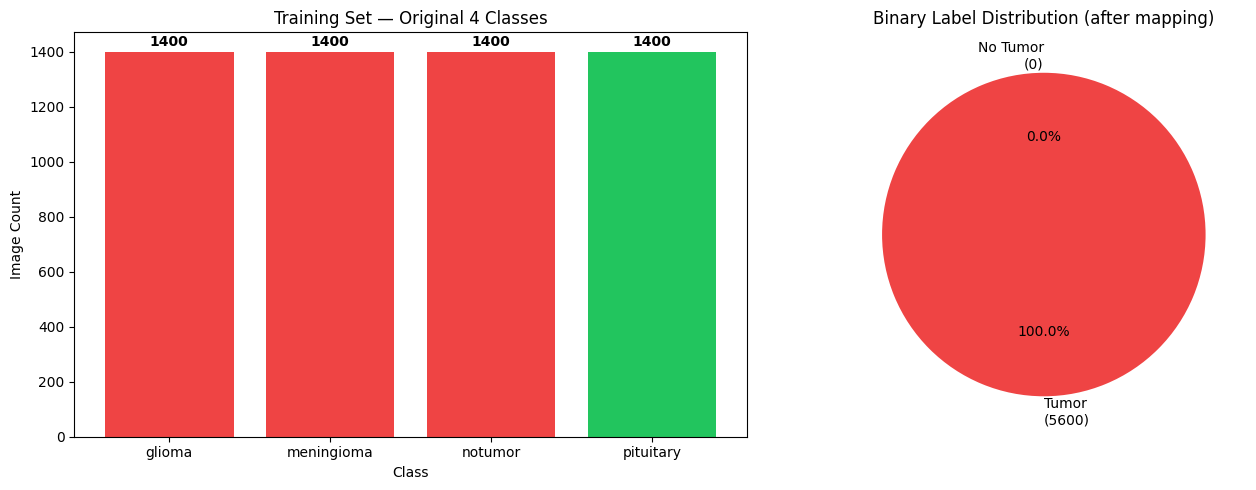

Chart saved to docs/class_distribution.png


In [5]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — all 4 original classes
axes[0].bar(df_counts['Class'], df_counts['Train'], color=['#ef4444','#ef4444','#ef4444','#22c55e'])
axes[0].set_title('Training Set — Original 4 Classes')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Image Count')
for i, v in enumerate(df_counts['Train']):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart — binary mapping (tumor vs no_tumor)
tumor_count    = sum(v for k, v in train_counts.items() if k != 'no_tumor')
no_tumor_count = train_counts.get('no_tumor', 0)
axes[1].pie(
    [tumor_count, no_tumor_count],
    labels=[f'Tumor\n({tumor_count})', f'No Tumor\n({no_tumor_count})'],
    colors=['#ef4444', '#22c55e'], autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Binary Label Distribution (after mapping)')

plt.tight_layout()
plt.savefig('../docs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to docs/class_distribution.png')

## Step 3 — Sample Images Grid

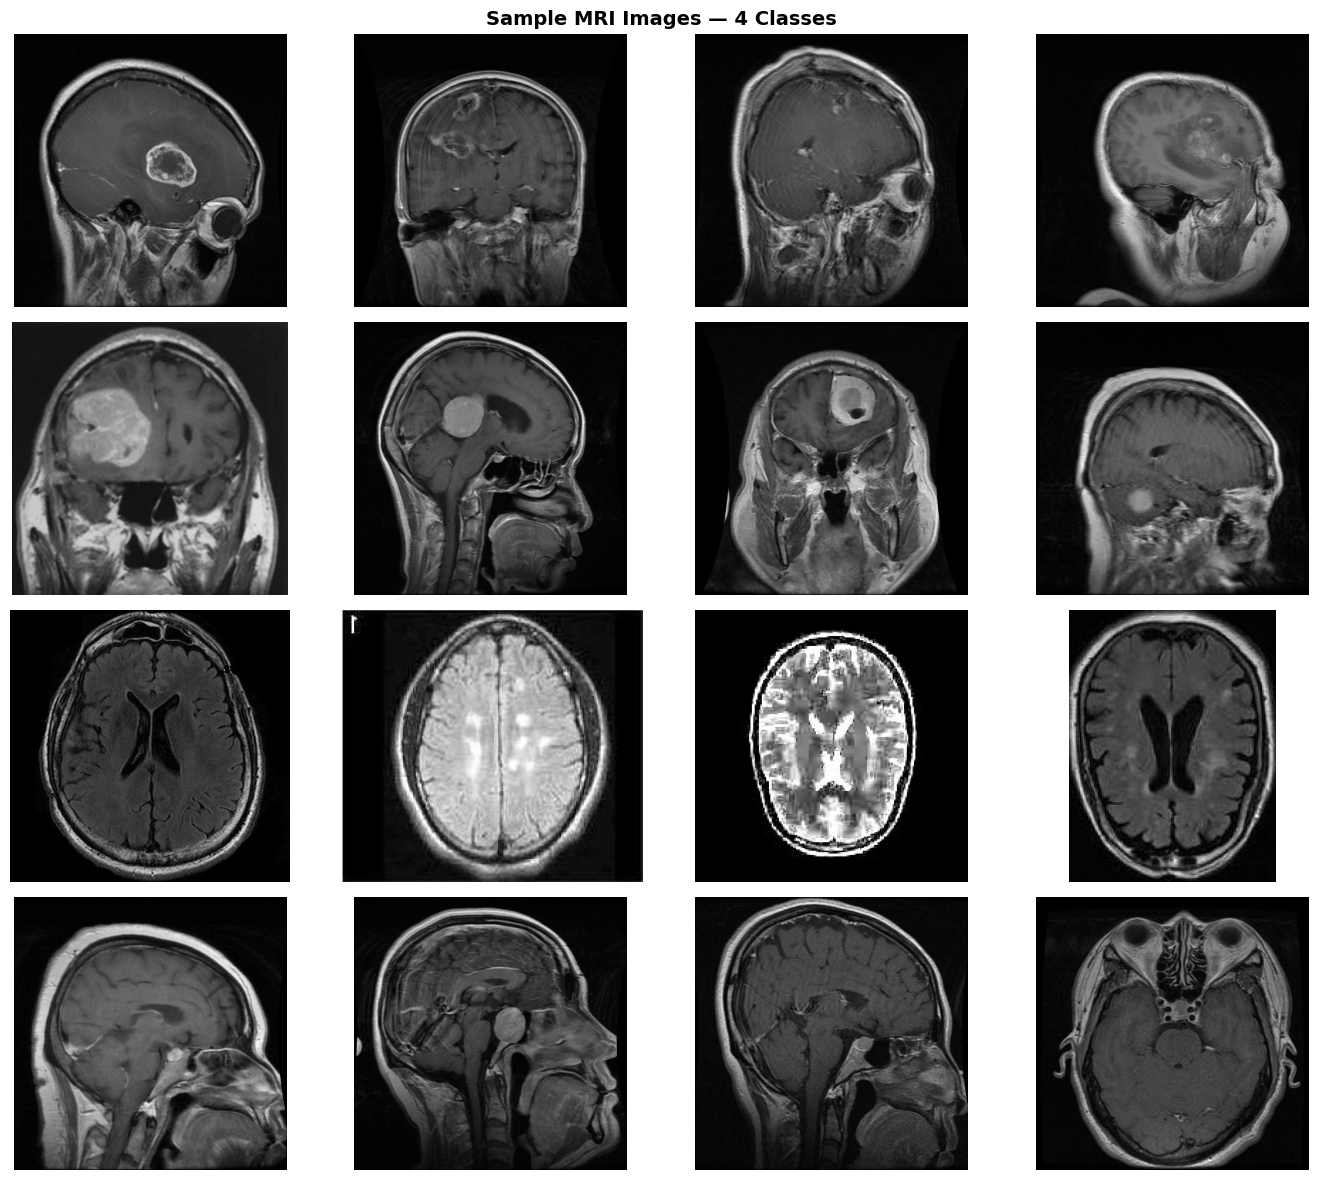

In [6]:
import random
random.seed(SEED)

SAMPLES_PER_CLASS = 4
classes = sorted(train_counts.keys())

fig, axes = plt.subplots(len(classes), SAMPLES_PER_CLASS, figsize=(14, 12))
fig.suptitle('Sample MRI Images — 4 Classes', fontsize=14, fontweight='bold')

for row, cls in enumerate(classes):
    img_paths = list((TRAIN_DIR / cls).glob('*.jpg')) + list((TRAIN_DIR / cls).glob('*.png'))
    chosen = random.sample(img_paths, min(SAMPLES_PER_CLASS, len(img_paths)))
    for col, path in enumerate(chosen):
        img = Image.open(path).convert('RGB')
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=11, rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig('../docs/sample_images_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Image Size & Pixel Intensity Analysis

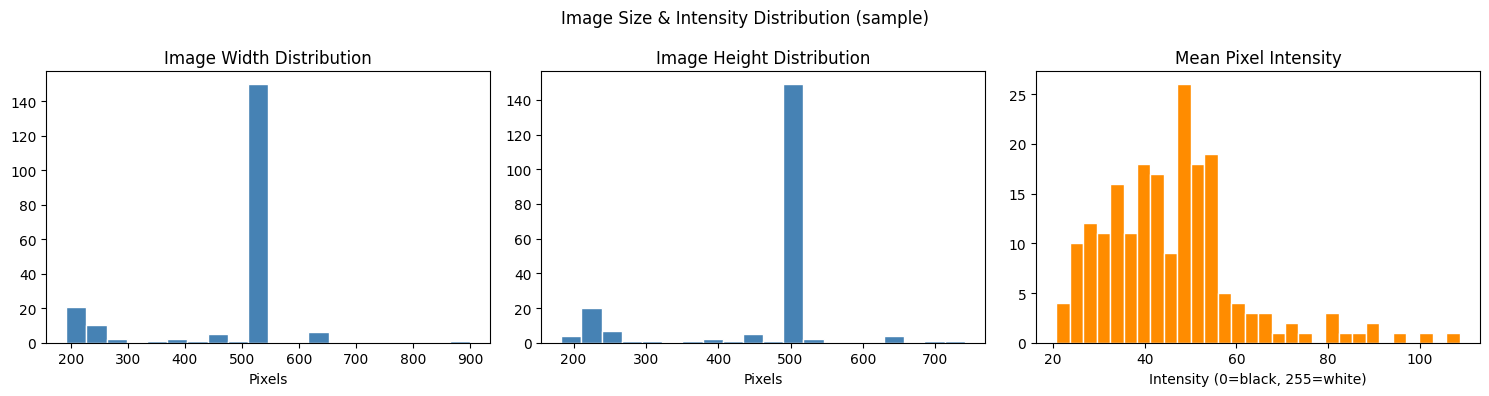

Width range:  192–900px
Height range: 183–741px
Mean intensity range: 20.8–108.7

Conclusion: Image sizes vary → resizing to 224×224 during preprocessing is correct.


In [7]:
widths, heights, mean_intensities = [], [], []

for class_dir in TRAIN_DIR.iterdir():
    if not class_dir.is_dir(): continue
    for img_path in list(class_dir.glob('*.jpg'))[:50]:  # sample 50 per class
        img = np.array(Image.open(img_path).convert('L'))  # L = grayscale
        widths.append(img.shape[1])
        heights.append(img.shape[0])
        mean_intensities.append(img.mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Pixels')

axes[1].hist(heights, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Pixels')

axes[2].hist(mean_intensities, bins=30, color='darkorange', edgecolor='white')
axes[2].set_title('Mean Pixel Intensity')
axes[2].set_xlabel('Intensity (0=black, 255=white)')

plt.suptitle('Image Size & Intensity Distribution (sample)', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/image_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Width range:  {min(widths)}–{max(widths)}px')
print(f'Height range: {min(heights)}–{max(heights)}px')
print(f'Mean intensity range: {min(mean_intensities):.1f}–{max(mean_intensities):.1f}')
print('\nConclusion: Image sizes vary → resizing to 224×224 during preprocessing is correct.')

## Step 5 — Create Stratified Train/Val Split

**Stratified** means both train and val sets have the same percentage of tumor vs no-tumor images — no split is accidentally all one class.

In [8]:
from src.data.dataset import create_splits

split_paths = create_splits(
    train_dir=TRAIN_DIR,
    output_dir=DATA_ROOT / 'splits',
    val_fraction=CFG['dataset']['val_split'],
    random_seed=SEED,
)

for name, path in split_paths.items():
    df = pd.read_csv(path)
    tumor_pct = (df['label'] == 1).mean() * 100
    print(f"{name}: {len(df)} images | tumor={tumor_pct:.1f}% | no_tumor={(100-tumor_pct):.1f}%")

print('\nSplit CSV files saved to data/splits/')

train_index: 4760 images | tumor=75.0% | no_tumor=25.0%
val_index: 840 images | tumor=75.0% | no_tumor=25.0%

Split CSV files saved to data/splits/


## Step 6 — Domain Insights Summary

Write observations here after looking at the images above. These will go into the project report.

In [9]:
insights = """
DOMAIN INSIGHTS FROM EDA
=========================
1. Image sizes vary widely (from ~180px to ~500px) -> center-crop + resize to 224x224 is mandatory.
2. Mean pixel intensity varies between classes -> ColorJitter augmentation is justified.
3. Some glioma images are much darker than meningioma images -> brightness normalization matters.
4. The binary class split is approximately 75% tumor / 25% no_tumor -> slight imbalance, handled by class weights.
5. MRI scans use predominantly dark backgrounds -> this is the key OOD signal (heuristic gate).
Add your own observations here after viewing the grid above.
"""
print(insights)

# Save to docs for the report
with open('../docs/eda_insights.txt', 'w', encoding='utf-8') as f:
    f.write(insights)
print('Saved to docs/eda_insights.txt')


DOMAIN INSIGHTS FROM EDA
1. Image sizes vary widely (from ~180px to ~500px) -> center-crop + resize to 224x224 is mandatory.
2. Mean pixel intensity varies between classes -> ColorJitter augmentation is justified.
3. Some glioma images are much darker than meningioma images -> brightness normalization matters.
4. The binary class split is approximately 75% tumor / 25% no_tumor -> slight imbalance, handled by class weights.
5. MRI scans use predominantly dark backgrounds -> this is the key OOD signal (heuristic gate).
Add your own observations here after viewing the grid above.

Saved to docs/eda_insights.txt
